In this notebook we will import a model trained on the UCD dataset and perform neural network pruning using a range of inverse models.

In [1]:
from sparseDPD import PGJANET_NeuralNetwork, PNTDNN_NeuralNetwork, ARVTDNN_NeuralNetwork
from sparseDPD import DataManager, Datapath, DatapathPruningExperiment, AdaptiveDatapathPruningExperiment, Volterra


simpleDataManager = DataManager(filepath='../UCD_datasets/PA_IO.mat', num_training_points=19000, num_validaiton_points=1000, num_test_points=2000)

# Load forward model
PGJANET_forward_nn = PGJANET_NeuralNetwork(num_memory_levels=15, model_type='PGJANETNetwork', nn_file_path='../pre_trained_models/pgjanet_checkpoint.pt')

Using cuda device


# PNTDNN one layer

Using cpu device
Epoch  10/50  Loss=7.3337e+00  Valid Loss=1.1493e+01  LR=1.00e-03
Epoch  20/50  Loss=5.2426e+00  Valid Loss=1.0948e+01  LR=1.00e-03
Epoch  30/50  Loss=4.3374e+00  Valid Loss=1.0200e+01  LR=1.00e-03
Epoch  40/50  Loss=3.7457e+00  Valid Loss=9.3674e+00  LR=1.00e-03
Epoch  50/50  Loss=3.2986e+00  Valid Loss=8.5192e+00  LR=1.00e-03

Best model from epoch 50 with validation loss: 8.5192e+00
Iteration 1/30 (Block 1/1, samples 0-19000) - NMSE: -6.7144 dB
--------------------------------------------------
Epoch  10/50  Loss=4.0832e+00  Valid Loss=5.2352e+00  LR=1.00e-03
Epoch  20/50  Loss=2.5245e+00  Valid Loss=3.4829e+00  LR=1.00e-03
Epoch  30/50  Loss=1.6256e+00  Valid Loss=2.6096e+00  LR=1.00e-03
Epoch  40/50  Loss=1.2539e+00  Valid Loss=2.1734e+00  LR=1.00e-03
Epoch  50/50  Loss=1.0456e+00  Valid Loss=1.9553e+00  LR=1.00e-03

Best model from epoch 50 with validation loss: 1.9553e+00
Iteration 2/30 (Block 1/1, samples 0-19000) - NMSE: -11.5705 dB
---------------------------

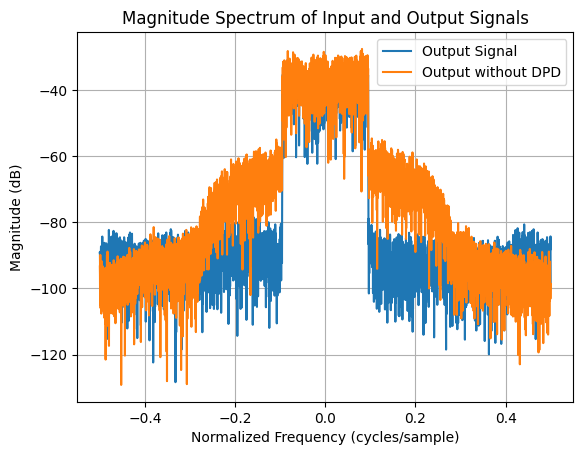

In [2]:
# Train an inverse model based on this forward model
# Instantiate a new PNTDNN model for training (one layer)

PNTDNN_inverse_nn = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type='OneLayerNetwork', nn_file_path=None, forward_model=False)
# Create a datapath with this model and the forward model
datapath_pntdnn_one_layer = Datapath(forward_model=PGJANET_forward_nn, inverse_model=PNTDNN_inverse_nn)

datapath_pntdnn_one_layer.train_using_ila(
    training_dataset = simpleDataManager.training_dataset,
    valid_dataset = simpleDataManager.validation_dataset,
    iterations = 30,
    retrain_epochs_per_iteration=50,
    seq_length=None
)

# find nmse
nmse = datapath_pntdnn_one_layer.calculate_nmse(simpleDataManager.test_dataset.input_data)
print(f"NMSE: {nmse:.4f} dB")

# Plot the spectrum 
datapath_pntdnn_one_layer.plot_spectrum(simpleDataManager.test_dataset.input_data[:5000])

In [3]:
# Save inverse model
PNTDNN_inverse_nn.write_nn_to_file('pntdnn_inverse_model.pt')

Using cuda device


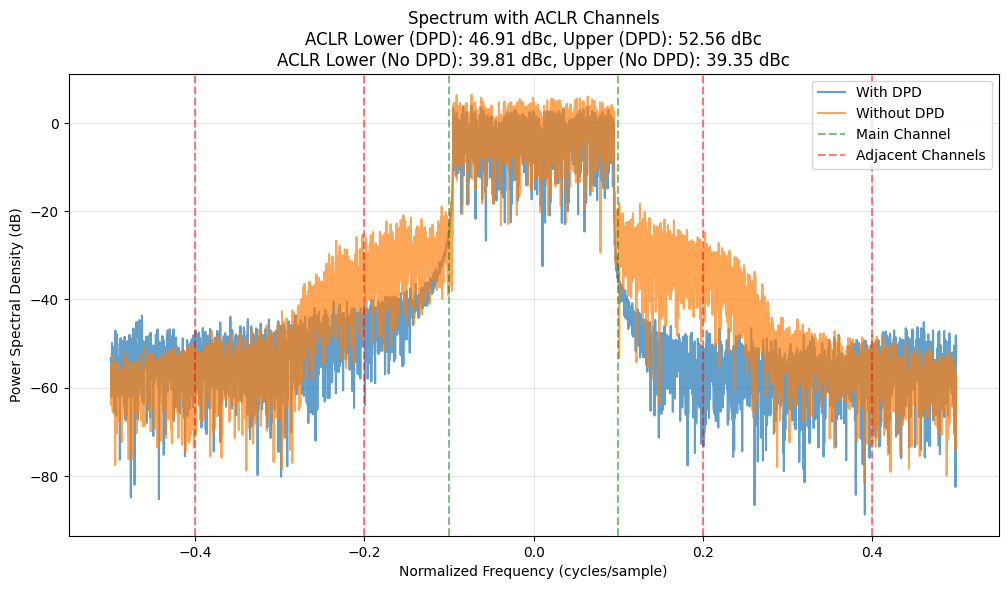

NMSE: (No DPD) -9.8468 dB


In [29]:
PNTDNN_inverse_nn = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type='OneLayerNetwork', nn_file_path='pntdnn_inverse_model.pt', forward_model=False)
datapath_pntdnn_one_layer = Datapath(forward_model=PGJANET_forward_nn, inverse_model=PNTDNN_inverse_nn)



datapath_pntdnn_one_layer.plot_spectrum_with_aclr(
    simpleDataManager.test_dataset.input_data[:5000],
    channel_bw=0.2,
    channel_spacing=0.3
)

print(f"NMSE: (No DPD) {simpleDataManager.test_dataset.calculate_nmse():.4f} dB")


Pruning Iteration 1/10
Pruning 20.0% of remaining weights...
Current pruning: 20.00% of weights are zero
Retraining for 50 epochs...
Epoch  10/50  Loss=6.4291e-02  Valid Loss=9.0295e-03  LR=1.00e-03
Epoch  20/50  Loss=5.9283e-02  Valid Loss=8.7185e-03  LR=1.00e-03
Epoch  30/50  Loss=5.8619e-02  Valid Loss=8.6364e-03  LR=1.00e-03
Epoch  40/50  Loss=5.8324e-02  Valid Loss=8.5743e-03  LR=1.00e-03
Epoch  50/50  Loss=5.8411e-02  Valid Loss=8.5727e-03  LR=1.00e-03

Best model from epoch 45 with validation loss: 8.5656e-03
Iteration 1/3 (Block 1/1, samples 0-19000) - NMSE: -40.4946 dB
--------------------------------------------------
Epoch  10/50  Loss=6.7793e-02  Valid Loss=8.3890e-03  LR=1.00e-03
Epoch  20/50  Loss=5.8994e-02  Valid Loss=8.1822e-03  LR=1.00e-03
Epoch  30/50  Loss=5.8743e-02  Valid Loss=8.1160e-03  LR=1.00e-03
Epoch  40/50  Loss=5.8558e-02  Valid Loss=8.0766e-03  LR=1.00e-03
Epoch  50/50  Loss=5.8399e-02  Valid Loss=8.0460e-03  LR=1.00e-03

Best model from epoch 50 with va

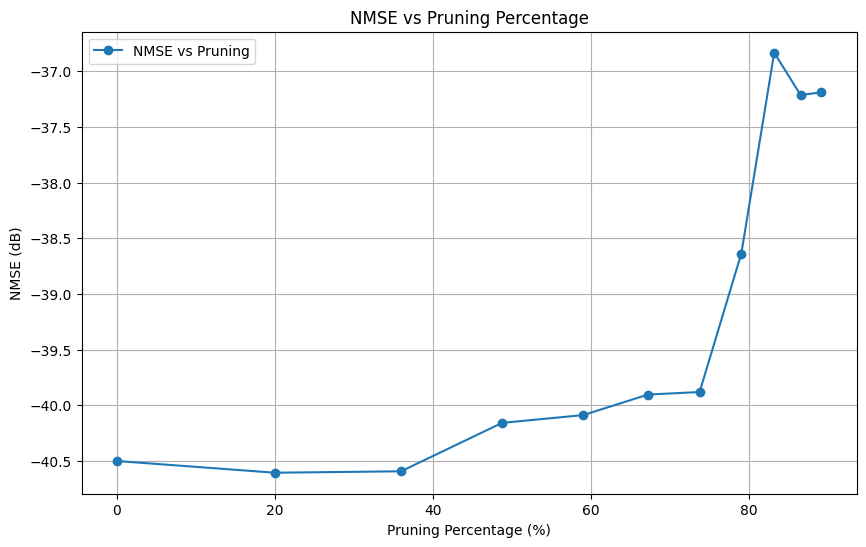

In [ ]:
# Now prune the inverse model and evaluate performance again
pruning_experiment_pntdnn_one_layer = DatapathPruningExperiment(
    datapath=datapath_pntdnn_one_layer,
    training_dataset=simpleDataManager.training_dataset,
    validation_dataset=simpleDataManager.validation_dataset,
    test_dataset=simpleDataManager.test_dataset,
    num_prune_iterations=10,
    prune_amount=0.2,
    retrain_epochs=50,
    ila_iterations=3,
    nmse_tolerance=-39.5,
    seq_length=None
)

pruning_experiment_pntdnn_one_layer.run()

# Save the best linear pruned inverse model
pruning_experiment_pntdnn_one_layer.best_datapath.inverse_model.write_nn_to_file('pntdnn_one_layer_fixed_percentage_pruned_inverse_model.pt')


Using cuda device
Sparsity of pruned model: 0.00%


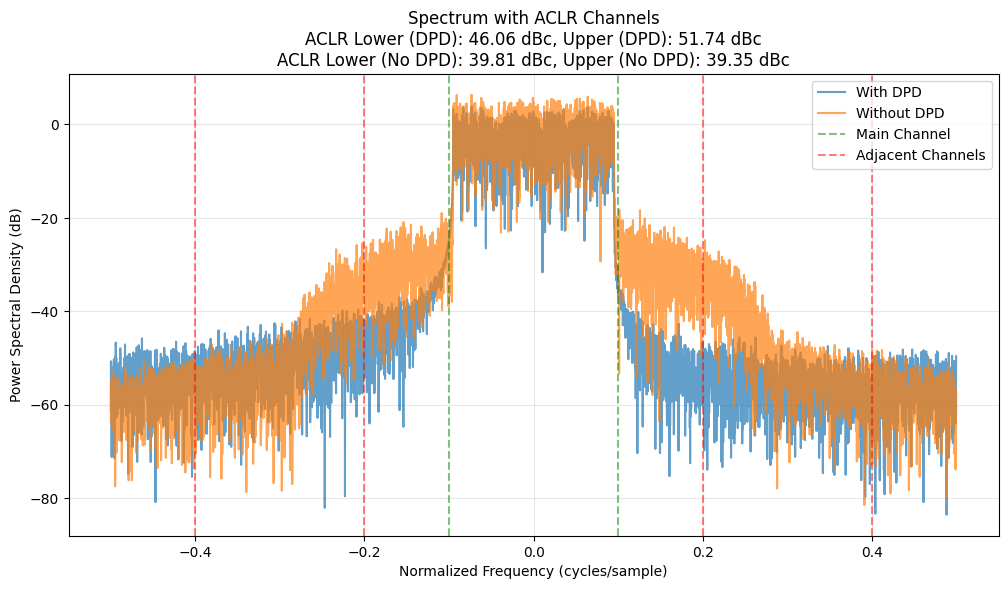

In [2]:
# Load best linear pruned model and evaluate performance
best_pruned_inverse_nn = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type='OneLayerNetwork', nn_file_path='pntdnn_one_layer_fixed_percentage_pruned_inverse_model.pt', forward_model=False)
#print sparsity of pruned model
print(f"Sparsity of pruned model: {best_pruned_inverse_nn._get_pruning_percentage():.2f}%")

best_pruned_datapath = Datapath(forward_model=PGJANET_forward_nn, inverse_model=best_pruned_inverse_nn)
# Plots for of best model
best_pruned_datapath.plot_spectrum_with_aclr(simpleDataManager.test_dataset.input_data[:5000], channel_bw=0.2, channel_spacing=0.3)


Step 1  |  fraction = 50.00%
Pruning 50.00% of remaining weights...
Current sparsity: 50.00% of weights are zero
Retraining for 50 epochs...
Epoch  10/50  Loss=3.3716e-01  Valid Loss=2.9662e-02  LR=1.00e-03
Epoch  20/50  Loss=2.3772e-01  Valid Loss=1.9540e-02  LR=1.00e-03
Epoch  30/50  Loss=1.9719e-01  Valid Loss=1.6640e-02  LR=1.00e-03
Epoch  40/50  Loss=1.7286e-01  Valid Loss=1.4853e-02  LR=1.00e-03
Epoch  50/50  Loss=1.5664e-01  Valid Loss=1.3635e-02  LR=1.00e-03

Best model from epoch 50 with validation loss: 1.3635e-02
Iteration 1/3 (Block 1/1, samples 0-19000) - NMSE: -37.4040 dB
--------------------------------------------------
Epoch  10/50  Loss=9.9613e-02  Valid Loss=1.1509e-02  LR=1.00e-03
Epoch  20/50  Loss=8.9961e-02  Valid Loss=1.0643e-02  LR=1.00e-03
Epoch  30/50  Loss=8.4511e-02  Valid Loss=1.0095e-02  LR=1.00e-03
Epoch  40/50  Loss=8.0542e-02  Valid Loss=9.7000e-03  LR=1.00e-03
Epoch  50/50  Loss=7.7672e-02  Valid Loss=9.4240e-03  LR=1.00e-03

Best model from epoch 50

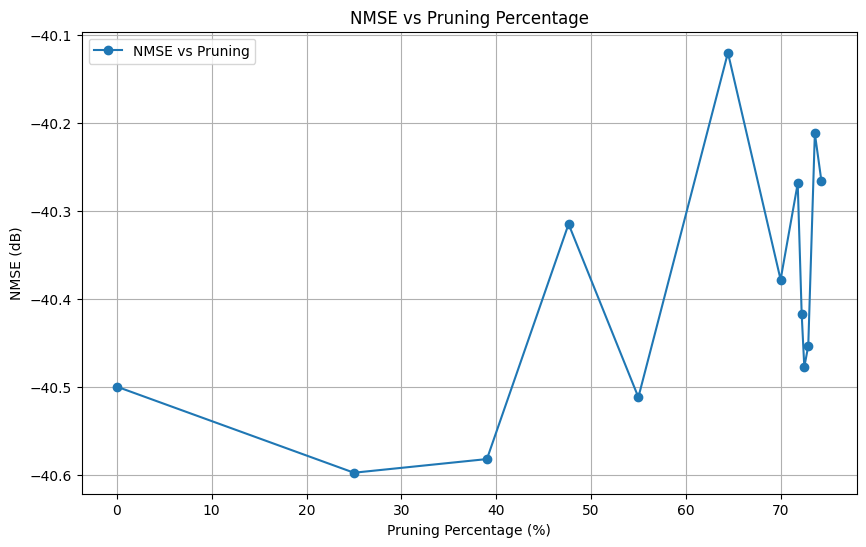

Best NMSE after pruning: -40.2663 dB


In [30]:
# Now try an adaptive pruning approach


adaptive_pruning_experiment = AdaptiveDatapathPruningExperiment(
    datapath=datapath_pntdnn_one_layer,
    training_dataset=simpleDataManager.training_dataset,
    validation_dataset=simpleDataManager.validation_dataset,
    test_dataset=simpleDataManager.test_dataset,
    retrain_epochs=50,
    ila_iterations = 3,
    initial_prune_fraction=0.5,
    max_prune_fraction=0.5,
    min_prune_fraction=0.01,
    nmse_tolerance=0.5
)

adaptive_pruning_experiment.run()

print("Best NMSE after pruning: {:.4f} dB".format(adaptive_pruning_experiment.best_datapath.calculate_nmse(simpleDataManager.test_dataset.input_data)))

In [12]:
# Save best adaptive pruned model
pntdnn_best_adaptive_pruned_model = adaptive_pruning_experiment.best_datapath.inverse_model
pntdnn_best_adaptive_pruned_model.write_nn_to_file('pntdnn_one_layer_adaptive_pruned_inverse_model_open.pt')

Using cuda device


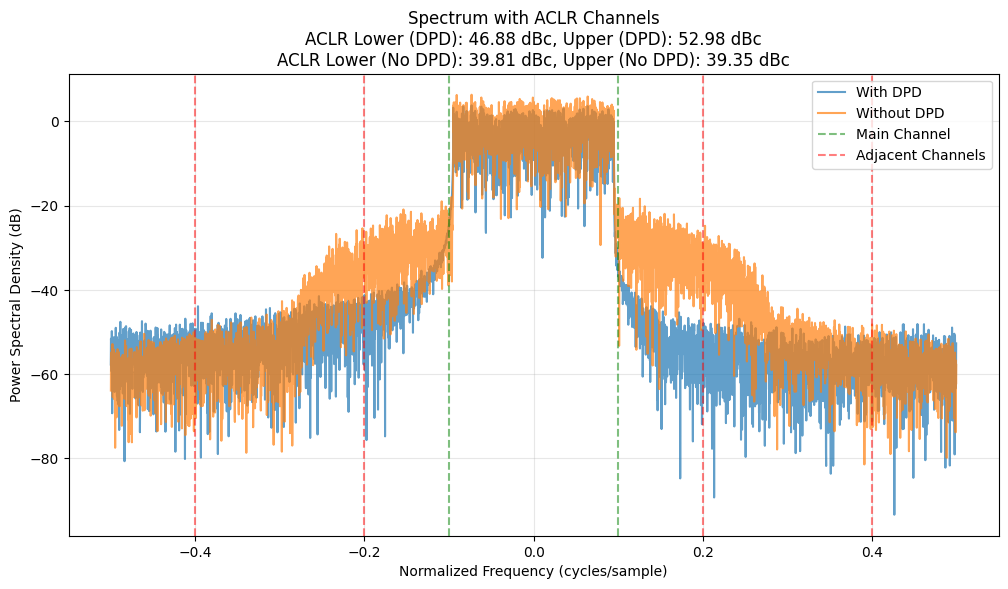

NMSE of best adaptive pruned model: -39.8157 dB


In [4]:
# load the adaptive best, and find its performance
best_adaptive_pruned_inverse_nn = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type='OneLayerNetwork', nn_file_path='pntdnn_one_layer_adaptive_pruned_inverse_model_open.pt', forward_model=False)
best_adaptive_pruned_datapath = Datapath(forward_model=PGJANET_forward_nn, inverse_model=best_adaptive_pruned_inverse_nn)
best_adaptive_pruned_datapath.plot_spectrum_with_aclr(simpleDataManager.test_dataset.input_data[:5000], channel_bw=0.2, channel_spacing=0.3)
print(f"NMSE of best adaptive pruned model: {best_adaptive_pruned_datapath.calculate_nmse(simpleDataManager.test_dataset.input_data):.4f} dB")

# PG-JANET one layer

Using cuda device
Epoch  10/80  Loss=1.3708e-02  Valid Loss=5.0557e+01  LR=1.00e-03
Epoch  20/80  Loss=8.4064e-03  Valid Loss=4.3211e+01  LR=1.00e-03
Epoch  30/80  Loss=5.0688e-03  Valid Loss=3.5998e+01  LR=1.00e-03
Epoch  40/80  Loss=2.9141e-03  Valid Loss=3.0666e+01  LR=1.00e-03
Epoch  50/80  Loss=2.4745e-03  Valid Loss=2.8769e+01  LR=1.00e-03
Epoch  60/80  Loss=2.3049e-03  Valid Loss=2.7490e+01  LR=1.00e-03
Epoch  70/80  Loss=2.4628e-03  Valid Loss=2.6652e+01  LR=1.00e-03
Epoch  80/80  Loss=2.2479e-03  Valid Loss=2.5872e+01  LR=1.00e-03

Best model from epoch 80 with validation loss: 2.5872e+01
Iteration 1/10 (Block 1/1, samples 0-19000) - NMSE: -3.3741 dB
--------------------------------------------------
Epoch  10/80  Loss=2.6232e-01  Valid Loss=1.1384e+01  LR=1.00e-03
Epoch  20/80  Loss=9.2302e-02  Valid Loss=5.8964e+00  LR=1.00e-03
Epoch  30/80  Loss=5.1382e-02  Valid Loss=4.1512e+00  LR=1.00e-03
Epoch  40/80  Loss=3.7112e-02  Valid Loss=3.5929e+00  LR=1.00e-03
Epoch  50/80  Los

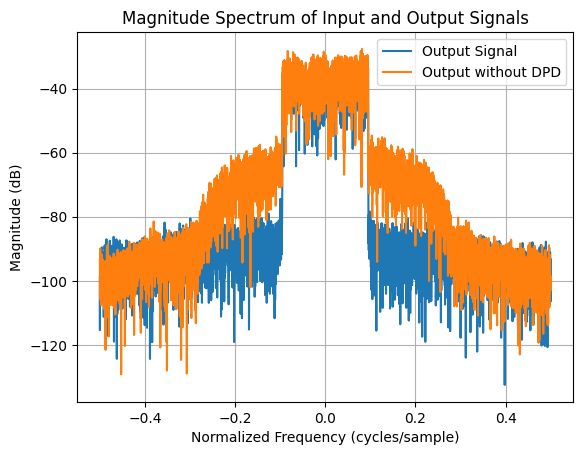

In [4]:
# Train an inverse model based on this forward model
# Instantiate a new PG-JANET model for training (one layer)

PGJANET_inverse_nn = PGJANET_NeuralNetwork(num_memory_levels=15, model_type='PGJANETNetwork', nn_file_path=None, forward_model=False, batch_size=512, hidden_size=16)
# Create a datapath with this model and the forward model
datapath_pgjanet_one_layer = Datapath(forward_model=PGJANET_forward_nn, inverse_model=PGJANET_inverse_nn)

datapath_pgjanet_one_layer.train_using_ila(
    training_dataset = simpleDataManager.training_dataset,
    valid_dataset = simpleDataManager.validation_dataset,
    iterations = 10,
    retrain_epochs_per_iteration=80,
    seq_length=None
)

# find nmse
nmse = datapath_pgjanet_one_layer.calculate_nmse(simpleDataManager.test_dataset.input_data)
print(f"NMSE: {nmse:.4f} dB")

# Plot the spectrum 
datapath_pgjanet_one_layer.plot_spectrum(simpleDataManager.test_dataset.input_data[:5000])

In [5]:
# Save inverse model
PGJANET_inverse_nn.write_nn_to_file('pgjanet_inverse_model_open.pt')

Using cuda device
Raw PA Output (no DPD):


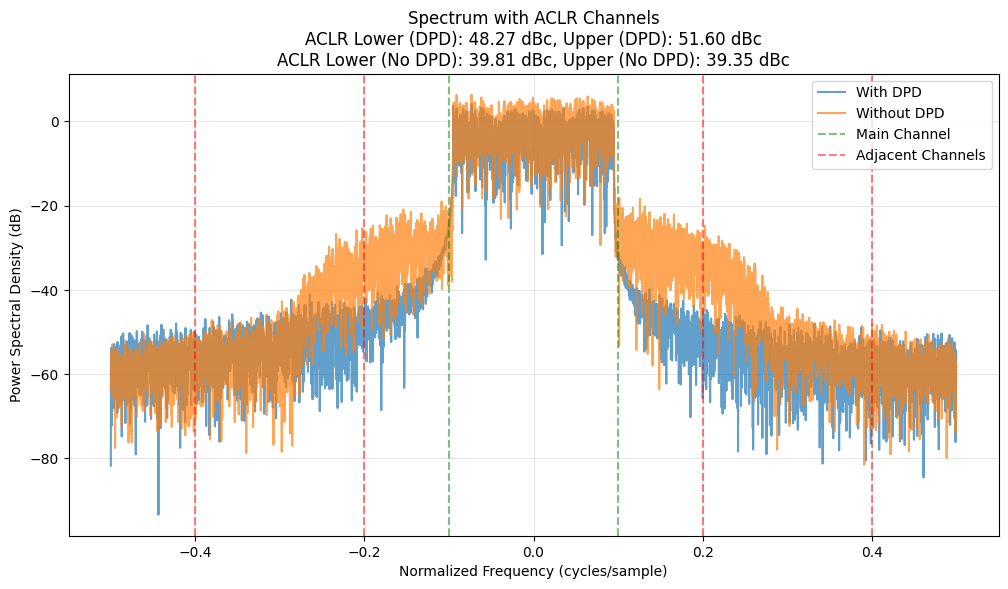

NMSE: (No DPD) -9.8468 dB


In [8]:
PGJANET_inverse_nn = PGJANET_NeuralNetwork(num_memory_levels=15, model_type='PGJANETNetwork', nn_file_path='pgjanet_inverse_model_open.pt', forward_model=False)
datapath_pgjanet_one_layer = Datapath(forward_model=PGJANET_forward_nn, inverse_model=PGJANET_inverse_nn)

# Evaluate model performance before pruning
openDPD_fs = 640e6  # Sampling frequency: 640 MHz
openDPD_bw_main_ch = 160e6  # Main channel bandwidth: 160 MHz
openDPD_bw_sub_ch = 40e6  # Sub-channel bandwidth: 40 MHz
openDPD_n_sub_ch = 4  # Number of sub-channels
openDPD_nperseg = 16384  # FFT size (frame length)

# Plot the QAM constellation - First check raw PA output (should be distorted)
print("Raw PA Output (no DPD):")

datapath_pgjanet_one_layer.plot_spectrum_with_aclr(
    simpleDataManager.test_dataset.input_data[:5000],
    channel_bw=0.2,
    channel_spacing=0.3
)

print(f"NMSE: (No DPD) {simpleDataManager.test_dataset.calculate_nmse():.4f} dB")


Pruning Iteration 1/10
Pruning 20.0% of remaining weights...
Current pruning: 19.98% of weights are zero
Retraining for 100 epochs...
Epoch  10/100  Loss=6.1610e-02  Valid Loss=1.1655e-02  LR=1.00e-03
Epoch  20/100  Loss=5.5467e-02  Valid Loss=1.2396e-02  LR=1.00e-03
Epoch  30/100  Loss=3.9301e-02  Valid Loss=1.1774e-02  LR=5.00e-04
Epoch  40/100  Loss=4.1528e-02  Valid Loss=1.1074e-02  LR=5.00e-04
Epoch  50/100  Loss=3.7000e-02  Valid Loss=1.0428e-02  LR=2.50e-04
Epoch  60/100  Loss=3.3671e-02  Valid Loss=1.0548e-02  LR=1.25e-04
Epoch  70/100  Loss=3.3211e-02  Valid Loss=1.1162e-02  LR=1.25e-04
Epoch  80/100  Loss=3.2453e-02  Valid Loss=1.0445e-02  LR=6.25e-05
Epoch  90/100  Loss=3.1693e-02  Valid Loss=1.0534e-02  LR=3.13e-05
Epoch 100/100  Loss=3.1530e-02  Valid Loss=1.0370e-02  LR=1.56e-05

Best model from epoch 62 with validation loss: 1.0281e-02
Iteration 1/1 (Block 1/1, samples 0-19000) - NMSE: -42.4964 dB
--------------------------------------------------
NMSE: -41.5492 dB

Pru

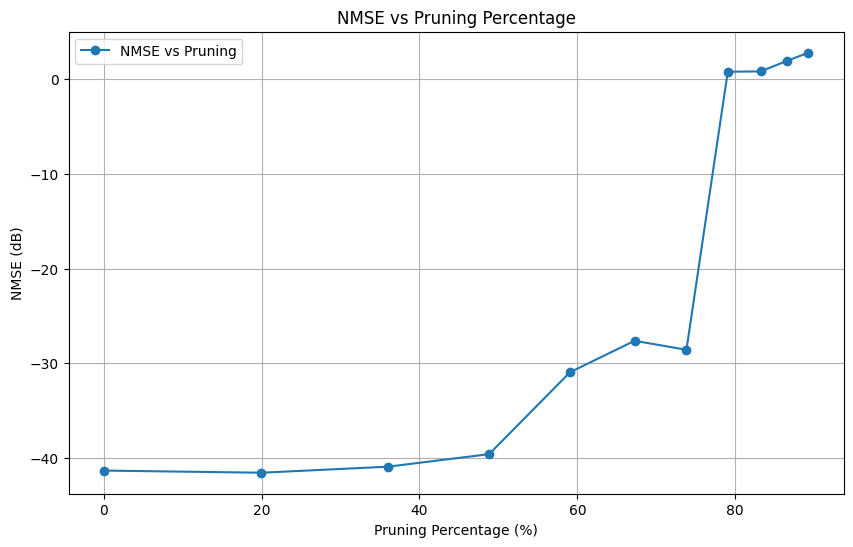

In [10]:
# Now prune the inverse model and evaluate performance again
pruning_experiment_pgjanet_one_layer = DatapathPruningExperiment(
    datapath=datapath_pgjanet_one_layer,
    training_dataset=simpleDataManager.training_dataset,
    validation_dataset=simpleDataManager.validation_dataset,
    test_dataset=simpleDataManager.test_dataset,
    num_prune_iterations=10,
    prune_amount=0.2,
    retrain_epochs=100,
    ila_iterations=1,
    nmse_tolerance=-40,
    seq_length=None
)

pruning_experiment_pgjanet_one_layer.run()

# Save the best linear pruned inverse model
pruning_experiment_pgjanet_one_layer.best_datapath.inverse_model.write_nn_to_file('pgjanet_one_layer_fixed_percentage_pruned_inverse_model_open.pt')

Using cuda device
Sparsity of pruned model: 0.00%


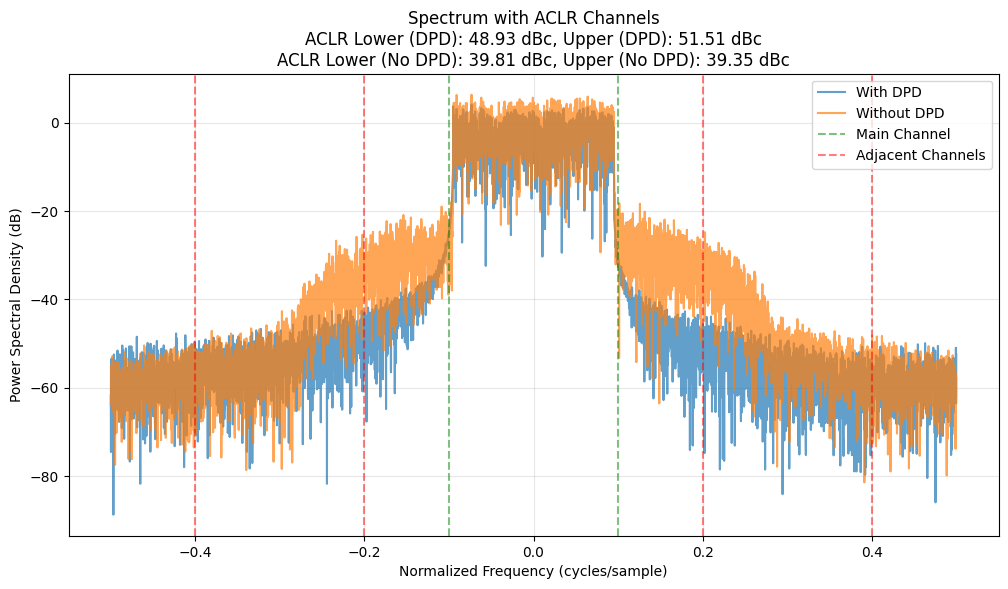

In [12]:
# Load best linear pruned model and evaluate performance
best_pruned_pgjanet_inverse_nn = PGJANET_NeuralNetwork(num_memory_levels=15, model_type='PGJANETNetwork', nn_file_path='pgjanet_one_layer_fixed_percentage_pruned_inverse_model_open.pt', forward_model=False)
#print sparsity of pruned model
print(f"Sparsity of pruned model: {best_pruned_pgjanet_inverse_nn._get_pruning_percentage():.2f}%")

best_pruned_pgjanet_datapath = Datapath(forward_model=PGJANET_forward_nn, inverse_model=best_pruned_pgjanet_inverse_nn)
# Plots for of best model
best_pruned_pgjanet_datapath.plot_spectrum_with_aclr(simpleDataManager.test_dataset.input_data[:5000], channel_bw=0.2, channel_spacing=0.3)


Step 1  |  fraction = 20.00%
Pruning 20.00% of remaining weights...
Current sparsity: 19.98% of weights are zero
Retraining for 100 epochs...
Epoch  10/100  Loss=5.6931e-02  Valid Loss=1.2870e-02  LR=1.00e-03
Epoch  20/100  Loss=4.8790e-02  Valid Loss=1.4286e-02  LR=1.00e-03
Epoch  30/100  Loss=5.3569e-02  Valid Loss=1.4241e-02  LR=1.00e-03
Epoch  40/100  Loss=4.8212e-02  Valid Loss=1.4093e-02  LR=1.00e-03
Epoch  50/100  Loss=3.8756e-02  Valid Loss=1.2039e-02  LR=5.00e-04
Epoch  60/100  Loss=3.7760e-02  Valid Loss=1.0523e-02  LR=5.00e-04
Epoch  70/100  Loss=3.8287e-02  Valid Loss=1.0127e-02  LR=5.00e-04
Epoch  80/100  Loss=3.5414e-02  Valid Loss=1.0844e-02  LR=5.00e-04
Epoch  90/100  Loss=3.1112e-02  Valid Loss=1.0172e-02  LR=2.50e-04
Epoch 100/100  Loss=2.9762e-02  Valid Loss=1.0295e-02  LR=1.25e-04

Best model from epoch 93 with validation loss: 1.0081e-02
Iteration 1/1 (Block 1/1, samples 0-19000) - NMSE: -42.8170 dB
--------------------------------------------------
NMSE: -41.8004

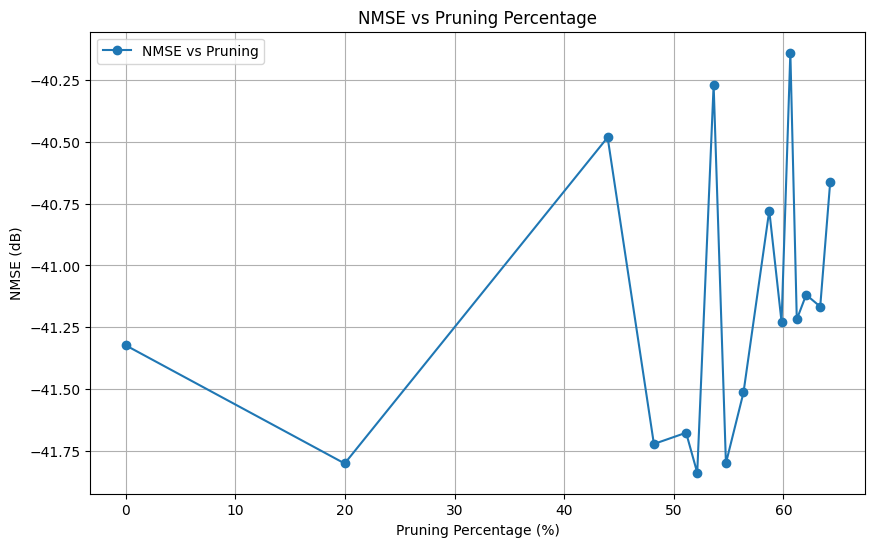

Best NMSE after pruning: -40.6638 dB


In [14]:
# Now try an adaptive pruning approach


adaptive_pruning_pgjanet_experiment = AdaptiveDatapathPruningExperiment(
    datapath=datapath_pgjanet_one_layer,
    training_dataset=simpleDataManager.training_dataset,
    validation_dataset=simpleDataManager.validation_dataset,
    test_dataset=simpleDataManager.test_dataset,
    retrain_epochs=100,
    ila_iterations = 1,
    initial_prune_fraction=0.2,
    max_prune_fraction=0.5,
    min_prune_fraction=0.01,
    nmse_tolerance=1.3226
)

adaptive_pruning_pgjanet_experiment.run()

print("Best NMSE after pruning: {:.4f} dB".format(adaptive_pruning_pgjanet_experiment.best_datapath.calculate_nmse(simpleDataManager.test_dataset.input_data)))

In [15]:
# Save best adaptive pruned model
pgjanet_best_adaptive_pruned_model = adaptive_pruning_pgjanet_experiment.best_datapath.inverse_model
pgjanet_best_adaptive_pruned_model.write_nn_to_file('pgjanet_one_layer_adaptive_pruned_inverse_model_open.pt')

Using cuda device


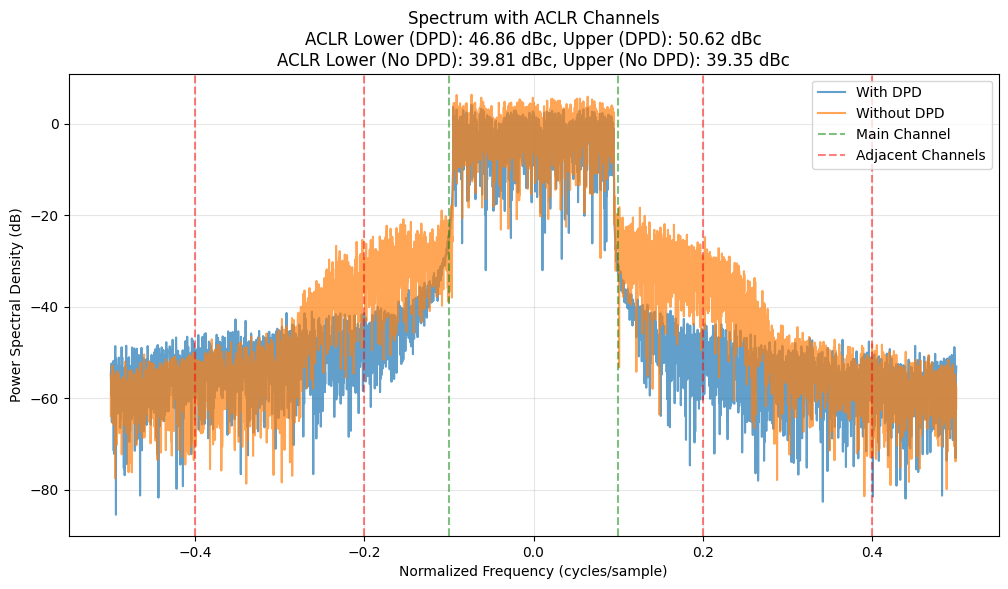

In [16]:
# load the adaptive best, and find its performance
best_adaptive_pruned_pgjanet_inverse_nn = PGJANET_NeuralNetwork(num_memory_levels=15, model_type='PGJANETNetwork', nn_file_path='pgjanet_one_layer_adaptive_pruned_inverse_model_open.pt', forward_model=False)
best_adaptive_pruned_pgjanet_datapath = Datapath(forward_model=PGJANET_forward_nn, inverse_model=best_adaptive_pruned_pgjanet_inverse_nn)
best_adaptive_pruned_pgjanet_datapath.plot_spectrum_with_aclr(simpleDataManager.test_dataset.input_data[:5000], channel_bw=0.2, channel_spacing=0.3)

# ARVTDNN one layer

Using cuda device
Epoch  10/100  Loss=1.7771e+01  Valid Loss=6.2771e+01  LR=1.00e-03
Epoch  20/100  Loss=9.3492e+00  Valid Loss=5.4562e+01  LR=1.00e-03
Epoch  30/100  Loss=5.6440e+00  Valid Loss=4.9973e+01  LR=1.00e-03
Epoch  40/100  Loss=3.8529e+00  Valid Loss=4.7683e+01  LR=1.00e-03
Epoch  50/100  Loss=2.7366e+00  Valid Loss=4.6505e+01  LR=1.00e-03
Epoch  60/100  Loss=2.0061e+00  Valid Loss=4.5581e+01  LR=1.00e-03
Epoch  70/100  Loss=1.5318e+00  Valid Loss=4.4719e+01  LR=1.00e-03
Epoch  80/100  Loss=1.2172e+00  Valid Loss=4.3756e+01  LR=1.00e-03
Epoch  90/100  Loss=9.9907e-01  Valid Loss=4.2656e+01  LR=1.00e-03
Epoch 100/100  Loss=8.4117e-01  Valid Loss=4.1407e+01  LR=1.00e-03

Best model from epoch 100 with validation loss: 4.1407e+01
Iteration 1/30 (Block 1/1, samples 0-19000) - NMSE: -0.6246 dB
--------------------------------------------------
Epoch  10/100  Loss=5.4936e+00  Valid Loss=3.3286e+01  LR=1.00e-03
Epoch  20/100  Loss=3.2433e+00  Valid Loss=2.8680e+01  LR=1.00e-03
Epoc

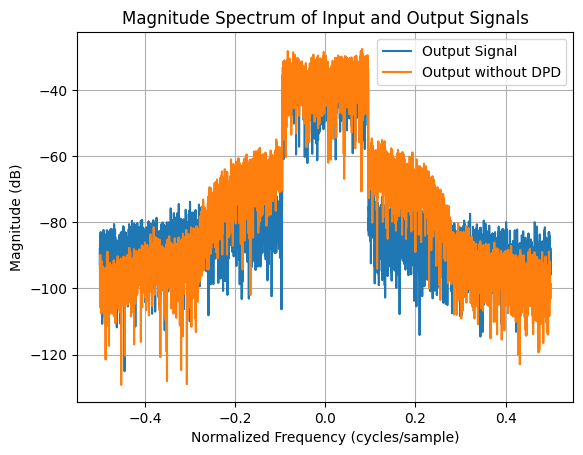

In [20]:
# Train an inverse model based on this forward model
# Instantiate a new PNTDNN model for training (one layer)

ARVTDNN_inverse_nn = ARVTDNN_NeuralNetwork(num_memory_levels=15, model_type='OneLayerNetwork', nn_file_path=None, forward_model=False)
# Create a datapath with this model and the forward model
datapath_arvtdnn_one_layer = Datapath(forward_model=PGJANET_forward_nn, inverse_model=ARVTDNN_inverse_nn)

datapath_arvtdnn_one_layer.train_using_ila(
    training_dataset = simpleDataManager.training_dataset,
    valid_dataset = simpleDataManager.validation_dataset,
    iterations = 30,
    retrain_epochs_per_iteration=100,
    seq_length=None
)

# find nmse
nmse = datapath_arvtdnn_one_layer.calculate_nmse(simpleDataManager.test_dataset.input_data)
print(f"NMSE: {nmse:.4f} dB")

# Plot the spectrum 
datapath_arvtdnn_one_layer.plot_spectrum(simpleDataManager.test_dataset.input_data[:5000])

# write to file 
ARVTDNN_inverse_nn.write_nn_to_file('arvtdnn_inverse_model_open.pt')

Using cuda device
Raw PA Output (no DPD):


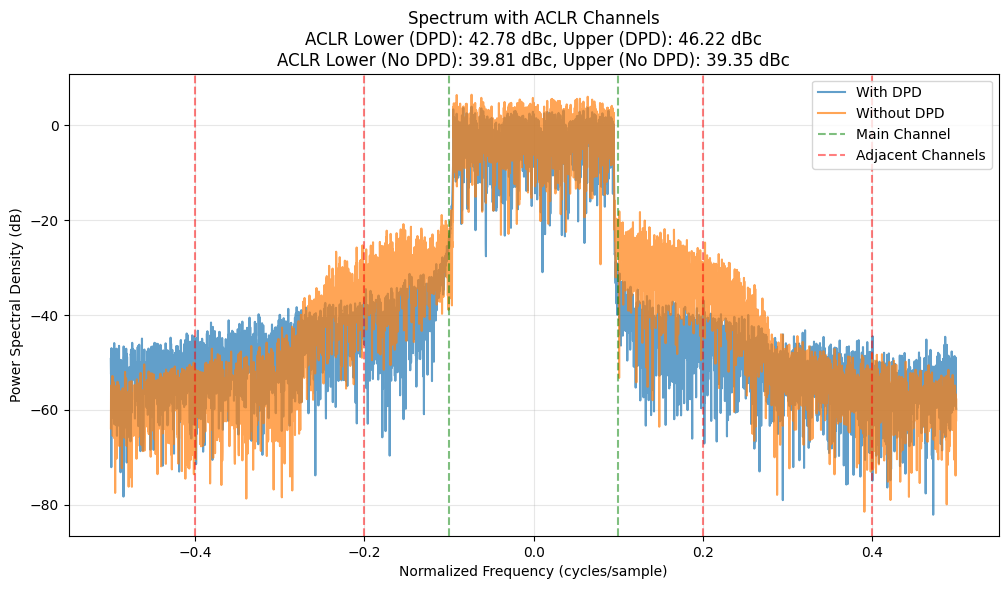

NMSE: (No DPD) -9.8468 dB


In [23]:
ARVTDNN_inverse_nn = ARVTDNN_NeuralNetwork(num_memory_levels=15, model_type='OneLayerNetwork', nn_file_path='arvtdnn_inverse_model_open.pt', forward_model=False)
datapath_arvtdnn_one_layer = Datapath(forward_model=PGJANET_forward_nn, inverse_model=ARVTDNN_inverse_nn)

# Evaluate model performance before pruning
openDPD_fs = 640e6  # Sampling frequency: 640 MHz
openDPD_bw_main_ch = 160e6  # Main channel bandwidth: 160 MHz
openDPD_bw_sub_ch = 40e6  # Sub-channel bandwidth: 40 MHz
openDPD_n_sub_ch = 4  # Number of sub-channels
openDPD_nperseg = 16384  # FFT size (frame length)

# Plot the QAM constellation - First check raw PA output (should be distorted)
print("Raw PA Output (no DPD):")

datapath_arvtdnn_one_layer.plot_spectrum_with_aclr(
    simpleDataManager.test_dataset.input_data[:5000],
    channel_bw=0.2,
    channel_spacing=0.3
)

print(f"NMSE: (No DPD) {simpleDataManager.test_dataset.calculate_nmse():.4f} dB")

In [ ]:
# Now prune the inverse model and evaluate performance again
pruning_experiment_arvtdnn_one_layer = DatapathPruningExperiment(
    datapath=datapath_arvtdnn_one_layer,
    training_dataset=simpleDataManager.training_dataset,
    validation_dataset=simpleDataManager.validation_dataset,
    test_dataset=simpleDataManager.test_dataset,
    num_prune_iterations=10,
    prune_amount=0.2,
    retrain_epochs=100,
    ila_iterations=1,
    nmse_tolerance=-40,
    seq_length=None
)

pruning_experiment_arvtdnn_one_layer.run()

# Save the best linear pruned inverse model
pruning_experiment_arvtdnn_one_layer.best_datapath.inverse_model.write_nn_to_file('arvtdnn_one_layer_fixed_percentage_pruned_inverse_model_open.pt')


Using cuda device
Sparsity of pruned model: 0.00%
Total subcarriers (1 carrier): 1024, Active (after guard band filtering): 982


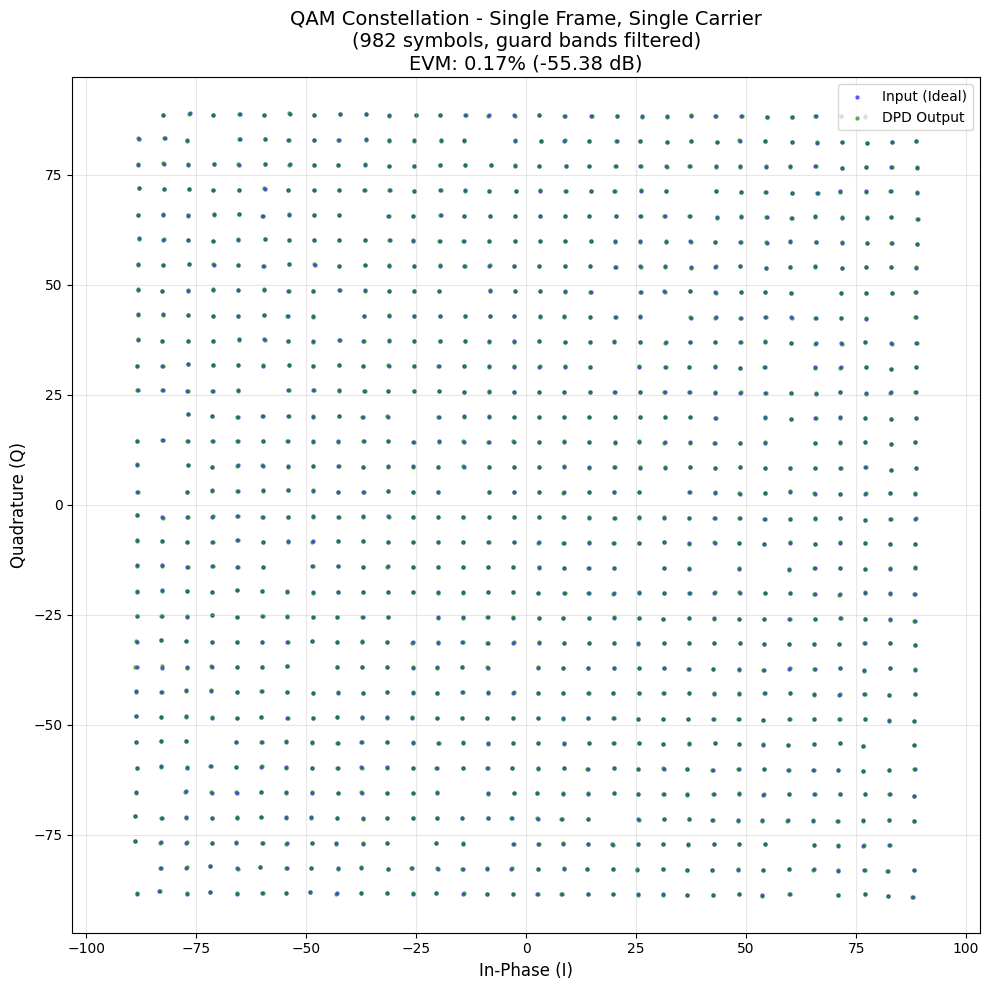

EVM (RMS): 0.170%
EVM (dB): -55.377 dB


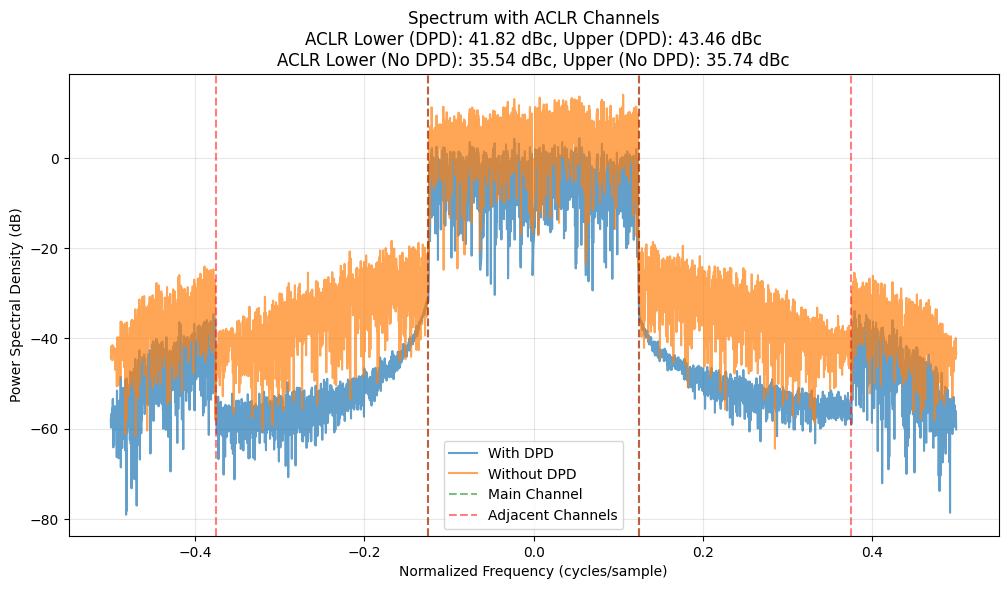

In [ ]:
# Load best linear pruned model and evaluate performance
best_pruned_inverse_nn = ARVTDNN_NeuralNetwork(num_memory_levels=15, model_type='OneLayerNetwork', nn_file_path='arvtdnn_one_layer_fixed_percentage_pruned_inverse_model_open.pt', forward_model=False)
#print sparsity of pruned model
print(f"Sparsity of pruned model: {best_pruned_inverse_nn._get_pruning_percentage():.2f}%")

best_pruned_datapath = Datapath(forward_model=PGJANET_forward_nn, inverse_model=best_pruned_inverse_nn)
# Plots for of best model
best_pruned_datapath.plot_constellation(simpleDataManager.training_dataset, fs = openDPD_fs, bw_sub_ch = openDPD_bw_sub_ch, n_sub_ch = openDPD_n_sub_ch, nperseg = openDPD_nperseg, show_dpd_output=True)
best_pruned_datapath.plot_spectrum_with_aclr(simpleDataManager.test_dataset.input_data[:5000], channel_bw=0.2, channel_bw=0.3)


Step 1  |  fraction = 20.00%
Pruning 20.00% of remaining weights...
Current sparsity: 20.03% of weights are zero
Retraining for 100 epochs...
Epoch  10/100  Loss=2.3785e-02  Valid Loss=1.4962e+01  LR=1.00e-03
Epoch  20/100  Loss=2.2811e-02  Valid Loss=1.5044e+01  LR=1.00e-03
Epoch  30/100  Loss=2.0689e-02  Valid Loss=1.5032e+01  LR=5.00e-04
Epoch  40/100  Loss=2.0375e-02  Valid Loss=1.4916e+01  LR=2.50e-04
Epoch  50/100  Loss=1.9832e-02  Valid Loss=1.5048e+01  LR=1.25e-04
Epoch  60/100  Loss=1.9705e-02  Valid Loss=1.5155e+01  LR=6.25e-05
Epoch  70/100  Loss=1.9643e-02  Valid Loss=1.5142e+01  LR=3.13e-05
Epoch  80/100  Loss=1.9442e-02  Valid Loss=1.5171e+01  LR=3.13e-05
Epoch  90/100  Loss=1.9319e-02  Valid Loss=1.5156e+01  LR=1.56e-05
Epoch 100/100  Loss=1.9273e-02  Valid Loss=1.5166e+01  LR=7.81e-06

Best model from epoch 37 with validation loss: 1.4897e+01
Iteration 1/1 (Block 1/1, samples 0-294912) - NMSE: -49.7646 dB
--------------------------------------------------
NMSE: -49.550

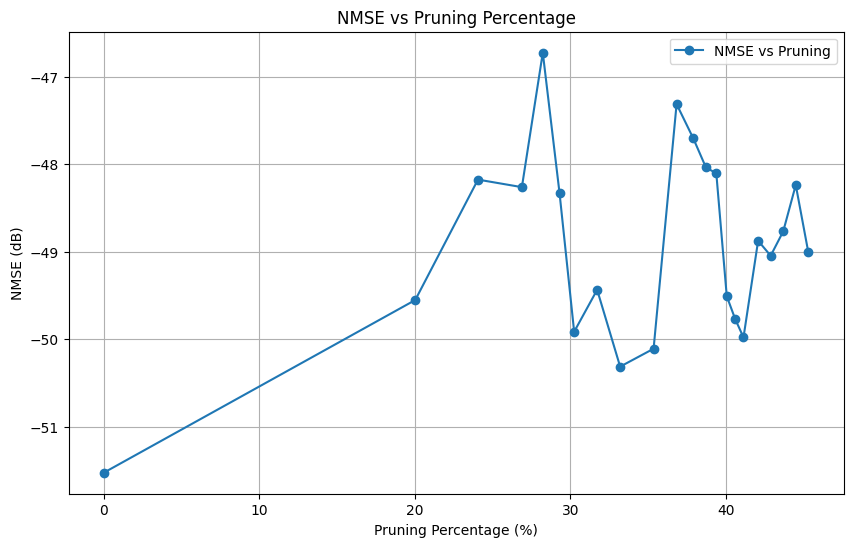

Best NMSE after pruning: -49.0043 dB


In [ ]:
# Now try an adaptive pruning approach


adaptive_pruning_experiment = AdaptiveDatapathPruningExperiment(
    datapath=datapath_arvtdnn_one_layer,
    training_dataset=simpleDataManager.training_dataset,
    validation_dataset=simpleDataManager.validation_dataset,
    test_dataset=simpleDataManager.test_dataset,
    retrain_epochs=100,
    ila_iterations = 1,
    initial_prune_fraction=0.2,
    max_prune_fraction=0.5,
    min_prune_fraction=0.01,
    nmse_tolerance=-40
)

adaptive_pruning_experiment.run()

print("Best NMSE after pruning: {:.4f} dB".format(adaptive_pruning_experiment.best_datapath.calculate_nmse(simpleDataManager.test_dataset.input_data)))

Using cuda device
Total subcarriers (1 carrier): 1024, Active (after guard band filtering): 982


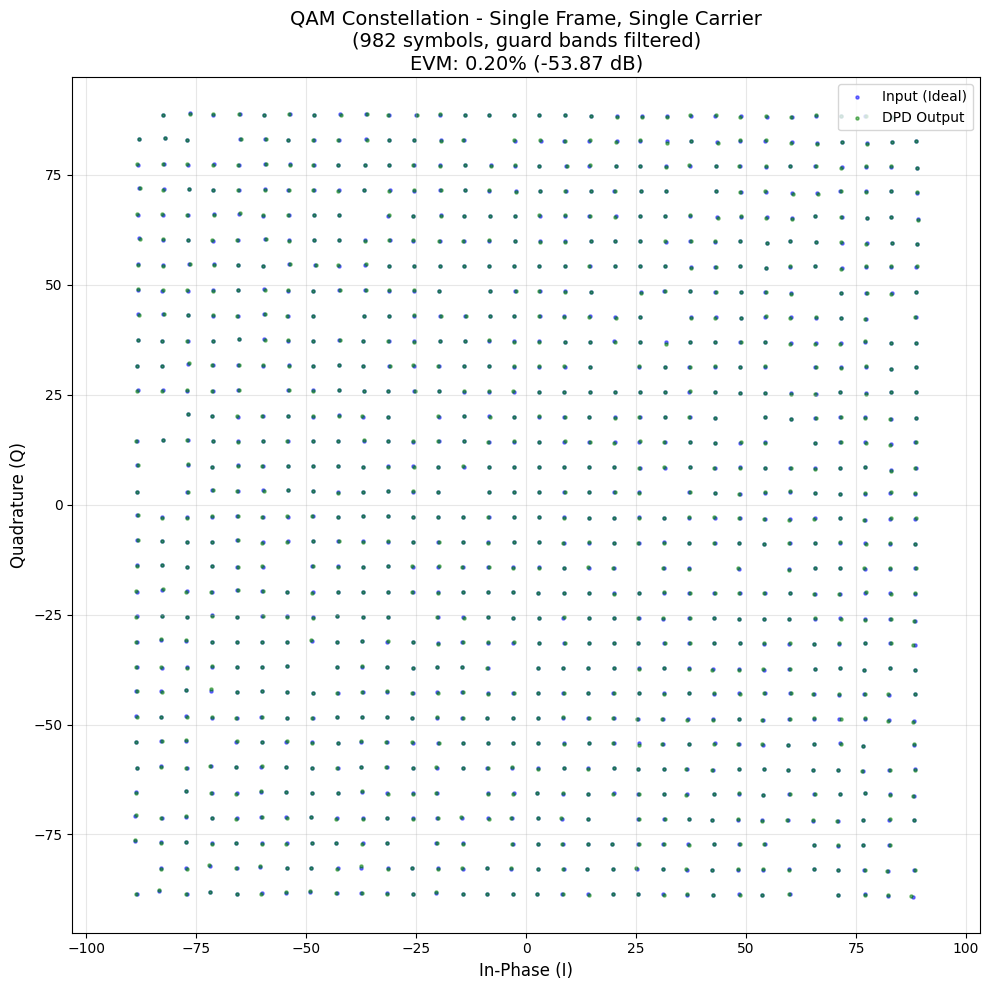

EVM (RMS): 0.203%
EVM (dB): -53.867 dB


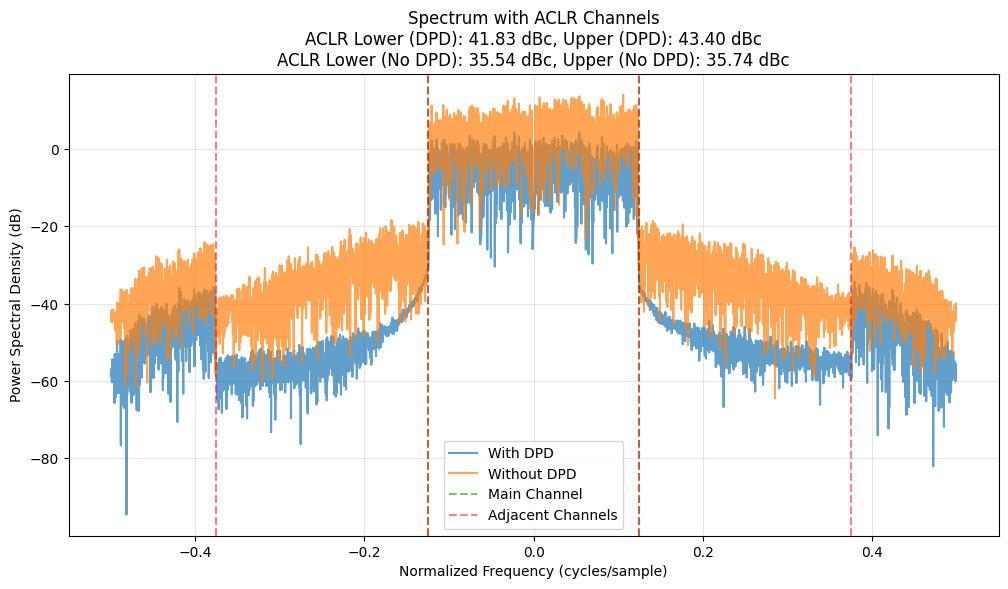

In [ ]:
# load the adaptive best, and find its performance
best_adaptive_pruned_inverse_nn = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type='OneLayerNetwork', nn_file_path='pntdnn_one_layer_adaptive_pruned_inverse_model_open.pt', forward_model=False)
best_adaptive_pruned_datapath = Datapath(forward_model=PGJANET_forward_nn, inverse_model=best_adaptive_pruned_inverse_nn)
best_adaptive_pruned_datapath.plot_constellation(simpleDataManager.training_dataset, fs = openDPD_fs, bw_sub_ch = openDPD_bw_sub_ch, n_sub_ch = openDPD_n_sub_ch, nperseg = openDPD_nperseg, show_dpd_output=True)
best_adaptive_pruned_datapath.plot_spectrum_with_aclr(simpleDataManager.test_dataset.input_data[:5000], channel_bw=0.2, channel_bw=0.3)

# PNTDNN Two Layer

Using cuda device
Epoch  10/200  Loss=2.0816e+00  Valid Loss=1.7608e+01  LR=1.00e-03
Epoch  20/200  Loss=1.4686e+00  Valid Loss=1.8242e+01  LR=5.00e-04
Epoch  30/200  Loss=1.3587e+00  Valid Loss=1.8272e+01  LR=2.50e-04
Epoch  40/200  Loss=1.3094e+00  Valid Loss=1.8268e+01  LR=1.25e-04
Epoch  50/200  Loss=1.2836e+00  Valid Loss=1.8258e+01  LR=6.25e-05
Epoch  60/200  Loss=1.2699e+00  Valid Loss=1.8251e+01  LR=3.13e-05
Epoch  70/200  Loss=1.2623e+00  Valid Loss=1.8247e+01  LR=3.13e-05
Epoch  80/200  Loss=1.2578e+00  Valid Loss=1.8245e+01  LR=1.56e-05
Epoch  90/200  Loss=1.2552e+00  Valid Loss=1.8244e+01  LR=7.81e-06
Epoch 100/200  Loss=1.2537e+00  Valid Loss=1.8243e+01  LR=3.91e-06
Epoch 110/200  Loss=1.2529e+00  Valid Loss=1.8242e+01  LR=1.95e-06
Epoch 120/200  Loss=1.2524e+00  Valid Loss=1.8242e+01  LR=9.77e-07
Epoch 130/200  Loss=1.2522e+00  Valid Loss=1.8242e+01  LR=4.88e-07
Epoch 140/200  Loss=1.2520e+00  Valid Loss=1.8242e+01  LR=2.44e-07
Epoch 150/200  Loss=1.2520e+00  Valid Loss=1

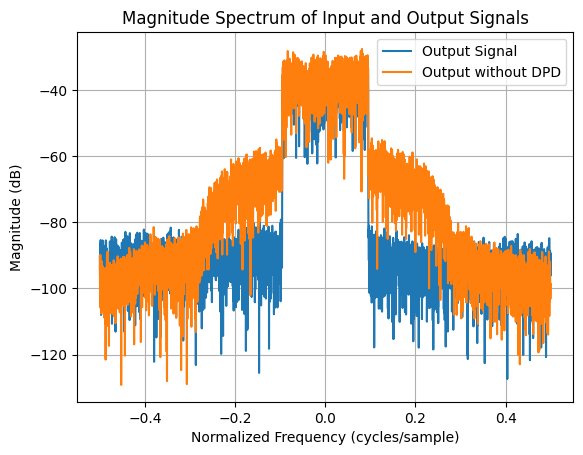

In [33]:
# Train an inverse model based on this forward model
# Instantiate a new PNTDNN model for training (two layers)

PNTDNN_three_layer_inverse_nn = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type='ThreeLayerNetwork', nn_file_path=None, forward_model=False)
# Create a datapath with this model and the forward model
datapath_pntdnn_three_layer = Datapath(forward_model=PGJANET_forward_nn, inverse_model=PNTDNN_three_layer_inverse_nn)

datapath_pntdnn_three_layer.train_using_ila(
    training_dataset = simpleDataManager.training_dataset,
    valid_dataset = simpleDataManager.validation_dataset,
    iterations = 20,
    retrain_epochs_per_iteration=200,
    seq_length=None
)

# find nmse
nmse = datapath_pntdnn_three_layer.calculate_nmse(simpleDataManager.test_dataset.input_data)
print(f"NMSE: {nmse:.4f} dB")

# Plot the spectrum 
datapath_pntdnn_three_layer.plot_spectrum(simpleDataManager.test_dataset.input_data[:5000])

# Save model
datapath_pntdnn_three_layer.inverse_model.write_nn_to_file('pntdnn_three_layer_inverse_model_open.pt')

Using cuda device
Raw PA Output (no DPD):


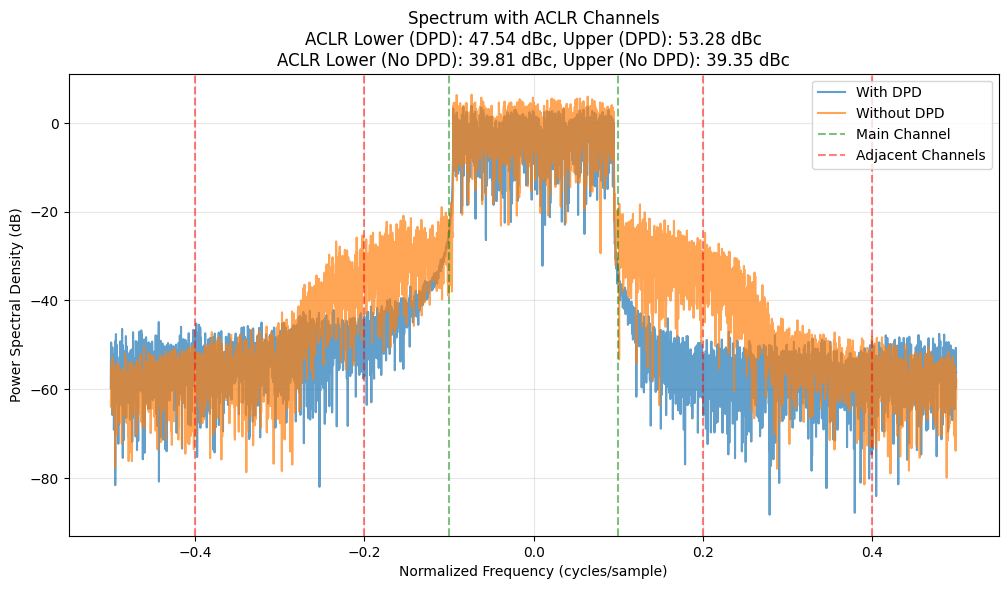

NMSE: (No DPD) -9.8468 dB


In [34]:
PNTDNN_three_layer_inverse_nn = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type='ThreeLayerNetwork', nn_file_path='pntdnn_three_layer_inverse_model_open.pt', forward_model=False)
datapath_pntdnn_three_layer = Datapath(forward_model=PGJANET_forward_nn, inverse_model=PNTDNN_three_layer_inverse_nn)

# Evaluate model performance before pruning
openDPD_fs = 640e6  # Sampling frequency: 640 MHz
openDPD_bw_main_ch = 160e6  # Main channel bandwidth: 160 MHz
openDPD_bw_sub_ch = 40e6  # Sub-channel bandwidth: 40 MHz
openDPD_n_sub_ch = 4  # Number of sub-channels
openDPD_nperseg = 16384  # FFT size (frame length)

# Plot the QAM constellation - First check raw PA output (should be distorted)
print("Raw PA Output (no DPD):")

datapath_pntdnn_three_layer.plot_spectrum_with_aclr(
    simpleDataManager.test_dataset.input_data[:5000],
    channel_bw=0.2,
    channel_spacing=0.3
)

print(f"NMSE: (No DPD) {simpleDataManager.test_dataset.calculate_nmse():.4f} dB")


Pruning Iteration 1/10
Pruning 20.0% of remaining weights...
Current pruning: 20.00% of weights are zero
Retraining for 200 epochs...
Epoch  10/200  Loss=6.4156e-02  Valid Loss=7.1489e-03  LR=1.00e-03
Epoch  20/200  Loss=5.5893e-02  Valid Loss=6.9910e-03  LR=1.00e-03
Epoch  30/200  Loss=5.5007e-02  Valid Loss=6.9437e-03  LR=1.00e-03
Epoch  40/200  Loss=5.4221e-02  Valid Loss=6.9420e-03  LR=1.00e-03
Epoch  50/200  Loss=5.3538e-02  Valid Loss=6.8686e-03  LR=5.00e-04
Epoch  60/200  Loss=5.3187e-02  Valid Loss=6.8470e-03  LR=5.00e-04
Epoch  70/200  Loss=5.3041e-02  Valid Loss=6.8483e-03  LR=5.00e-04
Epoch  80/200  Loss=5.2694e-02  Valid Loss=6.8515e-03  LR=2.50e-04
Epoch  90/200  Loss=5.2597e-02  Valid Loss=6.8453e-03  LR=2.50e-04
Epoch 100/200  Loss=5.2478e-02  Valid Loss=6.8434e-03  LR=1.25e-04
Epoch 110/200  Loss=5.2417e-02  Valid Loss=6.8422e-03  LR=6.25e-05
Epoch 120/200  Loss=5.2383e-02  Valid Loss=6.8417e-03  LR=3.13e-05
Epoch 130/200  Loss=5.2364e-02  Valid Loss=6.8416e-03  LR=1.5

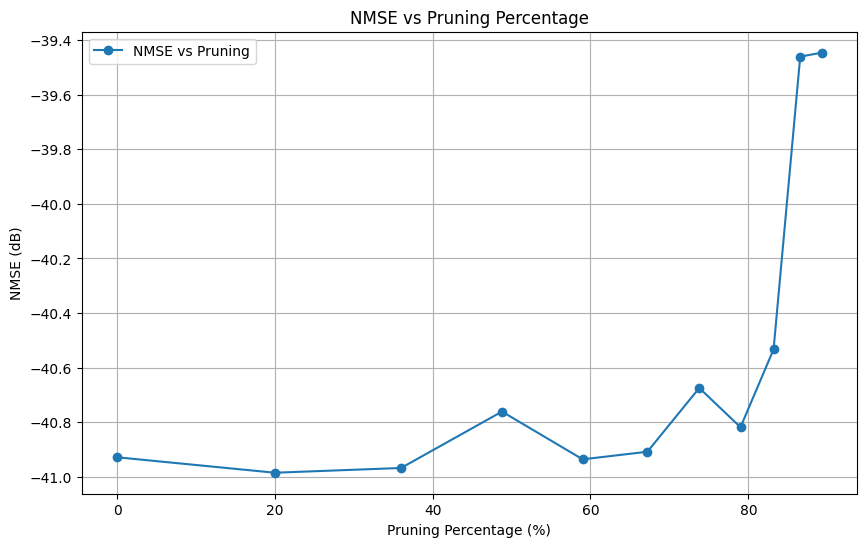

In [35]:
# Now prune the inverse model and evaluate performance again
pruning_experiment_pntdnn_three_layer = DatapathPruningExperiment(
    datapath=datapath_pntdnn_three_layer,
    training_dataset=simpleDataManager.training_dataset,
    validation_dataset=simpleDataManager.validation_dataset,
    test_dataset=simpleDataManager.test_dataset,
    num_prune_iterations=10,
    prune_amount=0.2,
    retrain_epochs=200,
    ila_iterations=3,
    nmse_tolerance=0.9277,
    seq_length=None
)

pruning_experiment_pntdnn_three_layer.run()

# Save the best linear pruned inverse model
pruning_experiment_pntdnn_three_layer.best_datapath.inverse_model.write_nn_to_file('pntdnn_three_layer_fixed_percentage_pruned_inverse_model_open.pt')


Using cuda device
Raw PA Output (no DPD):


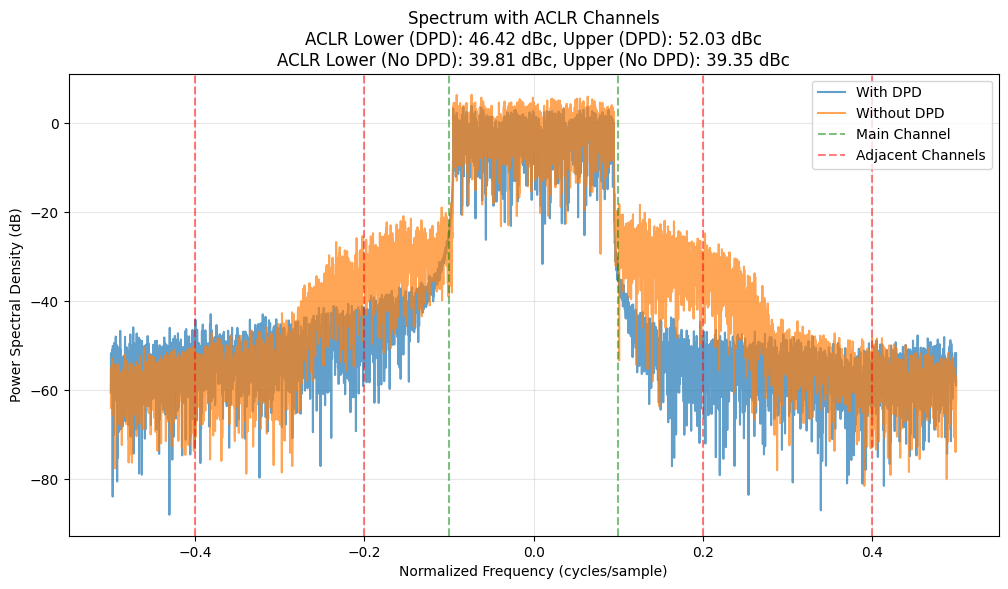

NMSE: (No DPD) -9.8468 dB


In [ ]:
best_fixed_PNTDNN_three_layer_inverse_nn = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type='ThreeLayerNetwork', nn_file_path='pntdnn_three_layer_fixed_percentage_pruned_inverse_model_open.pt', forward_model=False)
best_fixed_datapath_pntdnn_three_layer = Datapath(forward_model=PGJANET_forward_nn, inverse_model=best_fixed_PNTDNN_three_layer_inverse_nn)

# Evaluate model performance before pruning
openDPD_fs = 640e6  # Sampling frequency: 640 MHz
openDPD_bw_main_ch = 160e6  # Main channel bandwidth: 160 MHz
openDPD_bw_sub_ch = 40e6  # Sub-channel bandwidth: 40 MHz
openDPD_n_sub_ch = 4  # Number of sub-channels
openDPD_nperseg = 16384  # FFT size (frame length)

# Plot the QAM constellation - First check raw PA output (should be distorted)
print("Raw PA Output (no DPD):")

best_fixed_datapath_pntdnn_three_layer.plot_spectrum_with_aclr(
    simpleDataManager.test_dataset.input_data[:5000],
    channel_bw=0.2,
    channel_spacing=0.3
)

print(f"NMSE: (No DPD) {simpleDataManager.test_dataset.calculate_nmse():.4f} dB")


Step 1  |  fraction = 20.00%
Pruning 20.00% of remaining weights...
Current sparsity: 20.00% of weights are zero
Retraining for 100 epochs...
Epoch  10/100  Loss=6.4156e-02  Valid Loss=7.1489e-03  LR=1.00e-03
Epoch  20/100  Loss=5.5893e-02  Valid Loss=6.9910e-03  LR=1.00e-03
Epoch  30/100  Loss=5.5007e-02  Valid Loss=6.9437e-03  LR=1.00e-03
Epoch  40/100  Loss=5.4221e-02  Valid Loss=6.9420e-03  LR=1.00e-03
Epoch  50/100  Loss=5.3538e-02  Valid Loss=6.8686e-03  LR=5.00e-04
Epoch  60/100  Loss=5.3187e-02  Valid Loss=6.8470e-03  LR=5.00e-04
Epoch  70/100  Loss=5.3041e-02  Valid Loss=6.8483e-03  LR=5.00e-04
Epoch  80/100  Loss=5.2694e-02  Valid Loss=6.8515e-03  LR=2.50e-04
Epoch  90/100  Loss=5.2597e-02  Valid Loss=6.8453e-03  LR=2.50e-04
Epoch 100/100  Loss=5.2478e-02  Valid Loss=6.8434e-03  LR=1.25e-04

Best model from epoch 99 with validation loss: 6.8432e-03
Iteration 1/1 (Block 1/1, samples 0-19000) - NMSE: -41.2659 dB
--------------------------------------------------
NMSE: -41.0459

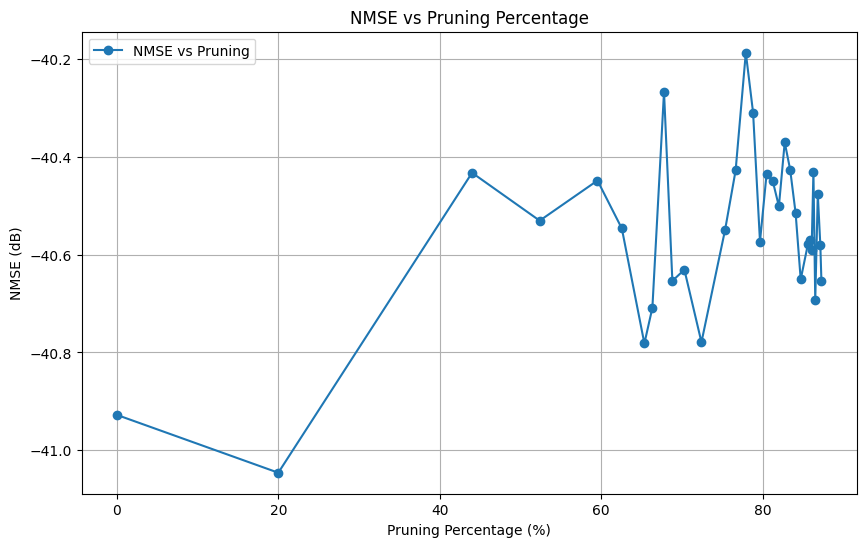

Best NMSE after pruning: -40.6547 dB


In [41]:
# Now try an adaptive pruning approach
adaptive_pruning_pntdnn_three_layer_experiment = AdaptiveDatapathPruningExperiment(
    datapath=datapath_pntdnn_three_layer,
    training_dataset=simpleDataManager.training_dataset,
    validation_dataset=simpleDataManager.validation_dataset,
    test_dataset=simpleDataManager.test_dataset,
    retrain_epochs=100,
    ila_iterations=1,
    initial_prune_fraction=0.2,
    max_prune_fraction=0.5,
    min_prune_fraction=0.01,
    nmse_tolerance=0.9277
)

adaptive_pruning_pntdnn_three_layer_experiment.run()

print("Best NMSE after pruning: {:.4f} dB".format(adaptive_pruning_pntdnn_three_layer_experiment.best_datapath.calculate_nmse(simpleDataManager.test_dataset.input_data)))

# Save the best adaptive pruned inverse model
adaptive_pruning_pntdnn_three_layer_experiment.best_datapath.inverse_model.write_nn_to_file('pntdnn_three_layer_adaptive_pruned_inverse_model_open.pt')

# PNTDNN multiLayer

Using cuda device
Epoch  10/10  Loss=5.3327e+02  Valid Loss=3.1983e+01  LR=1.00e-03

Best model from epoch 10 with validation loss: 3.1983e+01
Iteration 1/50 (Block 1/1, samples 0-19000) - NMSE: -1.9088 dB
--------------------------------------------------
Epoch  10/10  Loss=2.9640e+01  Valid Loss=7.4116e+00  LR=1.00e-03

Best model from epoch 10 with validation loss: 7.4116e+00
Iteration 2/50 (Block 1/1, samples 0-19000) - NMSE: -8.4318 dB
--------------------------------------------------
Epoch  10/10  Loss=5.9544e+00  Valid Loss=3.8653e+00  LR=1.00e-03

Best model from epoch 10 with validation loss: 3.8653e+00
Iteration 3/50 (Block 1/1, samples 0-19000) - NMSE: -11.0429 dB
--------------------------------------------------
Epoch  10/10  Loss=7.4255e+00  Valid Loss=1.7706e+00  LR=1.00e-03

Best model from epoch 10 with validation loss: 1.7706e+00
Iteration 4/50 (Block 1/1, samples 0-19000) - NMSE: -14.2493 dB
--------------------------------------------------
Epoch  10/10  Loss=6.321

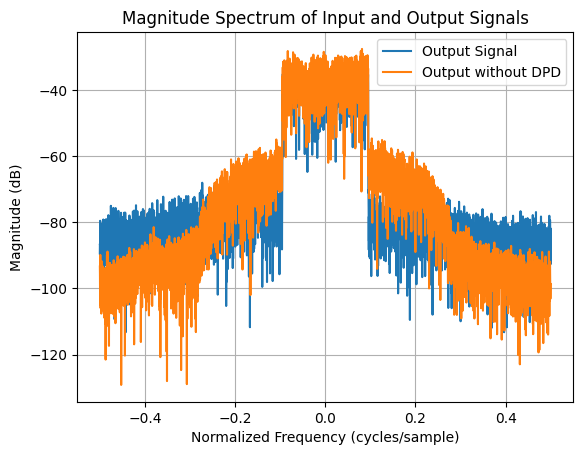

In [48]:
# Train an inverse model based on this forward model
# Instantiate a new PNTDNN model for training (multiLayer)

PNTDNN_multiLayer_inverse_nn = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type='MultiLayerNetwork', nn_file_path=None, forward_model=False)
# Create a datapath with this model and the forward model
datapath_pntdnn_multiLayer = Datapath(forward_model=PGJANET_forward_nn, inverse_model=PNTDNN_multiLayer_inverse_nn)

# Train the inverse model using ILA
datapath_pntdnn_multiLayer.train_using_ila(
    training_dataset = simpleDataManager.training_dataset,
    valid_dataset = simpleDataManager.validation_dataset,
    iterations = 50,
    retrain_epochs_per_iteration=10,
    seq_length=None
)

# find nmse
nmse = datapath_pntdnn_multiLayer.calculate_nmse(simpleDataManager.test_dataset.input_data)
print(f"NMSE: {nmse:.4f} dB")

# Plot the spectrum 
datapath_pntdnn_multiLayer.plot_spectrum(simpleDataManager.test_dataset.input_data[:5000])

# Save model
datapath_pntdnn_multiLayer.inverse_model.write_nn_to_file('pntdnn_multiLayer_inverse_model_open.pt')

In [ ]:
PNTDNN_multiLayer_inverse_nn = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type='multiLayer', nn_file_path='pntdnn_multiLayer_inverse_model_open.pt', forward_model=False)
datapath_pntdnn_multiLayer = Datapath(forward_model=PGJANET_forward_nn, inverse_model=PNTDNN_multiLayer_inverse_nn)

# Evaluate model performance before pruning
openDPD_fs = 640e6  # Sampling frequency: 640 MHz
openDPD_bw_main_ch = 160e6  # Main channel bandwidth: 160 MHz
openDPD_bw_sub_ch = 40e6  # Sub-channel bandwidth: 40 MHz
openDPD_n_sub_ch = 4  # Number of sub-channels
openDPD_nperseg = 16384  # FFT size (frame length)

# Plot the QAM constellation - First check raw PA output (should be distorted)
print("Raw PA Output (no DPD):")

datapath_pntdnn_multiLayer.plot_spectrum_with_aclr(
    simpleDataManager.test_dataset.input_data[:5000],
    channel_bw=0.2,
    channel_spacing=0.3
)

print(f"NMSE: (No DPD) {simpleDataManager.test_dataset.calculate_nmse():.4f} dB")

In [ ]:
# Now prune the inverse model and evaluate performance again
pruning_experiment_pntdnn_multiLayer = DatapathPruningExperiment(
    datapath=datapath_pntdnn_multiLayer,
    training_dataset=simpleDataManager.training_dataset,
    validation_dataset=simpleDataManager.validation_dataset,
    test_dataset=simpleDataManager.test_dataset,
    num_prune_iterations=10,
    prune_amount=0.2,
    retrain_epochs=200,
    ila_iterations=3,
    nmse_tolerance=0.9277,
    seq_length=None
)

pruning_experiment_pntdnn_multiLayer.run()

# Save the best linear pruned inverse model
pruning_experiment_pntdnn_multiLayer.best_datapath.inverse_model.write_nn_to_file('pntdnn_multiLayer_fixed_percentage_pruned_inverse_model_open.pt')


In [ ]:
best_adaptive_PNTDNN_multiLayer_inverse_nn = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type='multiLayer', nn_file_path='pntdnn_multiLayer_fixed_percentage_pruned_inverse_model_open.pt', forward_model=False)
best_adaptive_datapath_pntdnn_multiLayer = Datapath(forward_model=PGJANET_forward_nn, inverse_model=best_adaptive_PNTDNN_multiLayer_inverse_nn)

# Evaluate model performance before pruning
openDPD_fs = 640e6  # Sampling frequency: 640 MHz
openDPD_bw_main_ch = 160e6  # Main channel bandwidth: 160 MHz
openDPD_bw_sub_ch = 40e6  # Sub-channel bandwidth: 40 MHz
openDPD_n_sub_ch = 4  # Number of sub-channels
openDPD_nperseg = 16384  # FFT size (frame length)

# Plot the QAM constellation - First check raw PA output (should be distorted)
print("Raw PA Output (no DPD):")

best_adaptive_datapath_pntdnn_multiLayer.plot_spectrum_with_aclr(
    simpleDataManager.test_dataset.input_data[:5000],
    channel_bw=0.2,
    channel_spacing=0.3
)

print(f"NMSE: (No DPD) {simpleDataManager.test_dataset.calculate_nmse():.4f} dB")

ILA Iteration 1/10 - NMSE: -38.2241 dB
ILA Iteration 2/10 - NMSE: -38.2687 dB
ILA Iteration 3/10 - NMSE: -38.2638 dB
ILA Iteration 4/10 - NMSE: -38.2585 dB
ILA Iteration 5/10 - NMSE: -38.2561 dB
ILA Iteration 6/10 - NMSE: -38.2549 dB
ILA Iteration 7/10 - NMSE: -38.2543 dB
ILA Iteration 8/10 - NMSE: -38.2540 dB
ILA Iteration 9/10 - NMSE: -38.2539 dB
ILA Iteration 10/10 - NMSE: -38.2538 dB
{'aclr_lower_dpd': np.float32(51.181927), 'aclr_upper_dpd': np.float32(53.726254), 'aclr_lower_no_dpd': np.float32(40.235676), 'aclr_upper_no_dpd': np.float32(40.412926)}


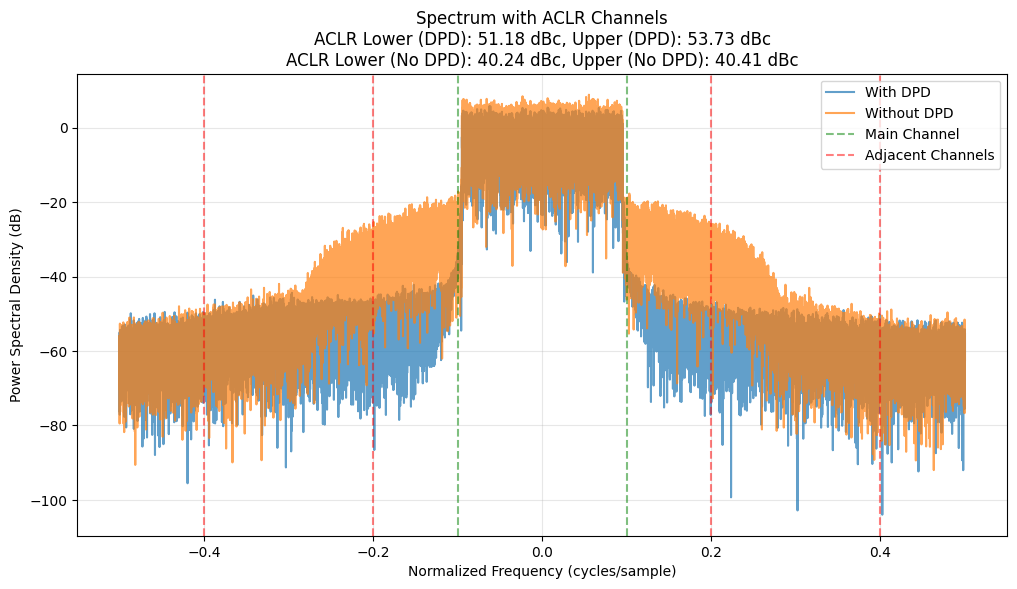

In [56]:
# Create a Volterra inverse model and train with iterative ILA
from sparseDPD import Dataset

volterra_inv = Volterra(
    num_memory_levels=5,
    num_nl_orders=5,
    dataset=simpleDataManager.training_dataset,
    forward=False
)

# Create a datapath with this model
datapath_volterra_inv = Datapath(forward_model=PGJANET_forward_nn, inverse_model=volterra_inv)

# Iterative ILA for Volterra using retrain()
ila_iterations = 10
for iteration in range(ila_iterations):
    # Inverse model predistortion
    inverse_model_output = volterra_inv.generate_model_output(simpleDataManager.training_dataset.input_data)

    # Forward-model response to predistorted signal
    forward_model_output = PGJANET_forward_nn.generate_model_output(inverse_model_output)

    # Align for forward model trimming (same idea as train_using_ila)
    trim_forward = datapath_volterra_inv._get_model_trim_amount(PGJANET_forward_nn)
    aligned_input = inverse_model_output[trim_forward:]

    # Retrain Volterra inverse on ILA-generated dataset
    ila_dataset = Dataset(input_data=aligned_input, output_data=forward_model_output)
    volterra_inv.retrain(ila_dataset)

    # Track test NMSE after each ILA iteration
    nmse = datapath_volterra_inv.calculate_nmse(simpleDataManager.test_dataset.input_data)
    print(f"ILA Iteration {iteration+1}/{ila_iterations} - NMSE: {nmse:.4f} dB")

print(datapath_volterra_inv.calculate_aclr(
    input_data=simpleDataManager.test_dataset.input_data,
    channel_bw=0.2,
    channel_spacing=0.3
))

datapath_volterra_inv.plot_spectrum_with_aclr(
    input_data=simpleDataManager.test_dataset.input_data,
    channel_bw=0.2,
    channel_spacing=0.3
)


Training with retrain_epochs_per_iteration=20
Using cuda device
Epoch  10/20  Loss=2.6540e+01  Valid Loss=1.6304e+01  LR=1.00e-03
Epoch  20/20  Loss=2.0442e+01  Valid Loss=1.4909e+01  LR=1.00e-03

Best model from epoch 20 with validation loss: 1.4909e+01
Iteration 1/30 (Block 1/1, samples 0-19000) - NMSE: -5.6039 dB
--------------------------------------------------
Epoch  10/20  Loss=1.0625e+01  Valid Loss=7.6495e+00  LR=1.00e-03
Epoch  20/20  Loss=6.2321e+00  Valid Loss=4.6407e+00  LR=1.00e-03

Best model from epoch 20 with validation loss: 4.6407e+00
Iteration 2/30 (Block 1/1, samples 0-19000) - NMSE: -8.5673 dB
--------------------------------------------------
Epoch  10/20  Loss=3.7649e+00  Valid Loss=1.7113e+00  LR=1.00e-03
Epoch  20/20  Loss=2.0246e+00  Valid Loss=1.1256e+00  LR=1.00e-03

Best model from epoch 20 with validation loss: 1.1256e+00
Iteration 3/30 (Block 1/1, samples 0-19000) - NMSE: -12.5853 dB
--------------------------------------------------
Epoch  10/20  Loss=

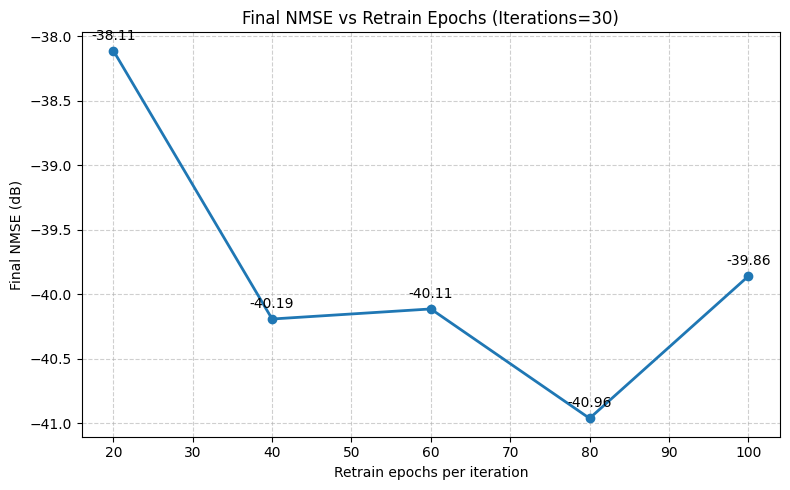

Best setting: 80 epochs -> NMSE -40.9631 dB


In [2]:
# Sweep retrain epochs and compare final NMSE (PNTDNN one-layer inverse model)
import matplotlib.pyplot as plt

epoch_values = list(range(20, 101, 20))  # 20, 40, 60, 80, 100
nmse_results = []

for retrain_epochs in epoch_values:
    print(f"\nTraining with retrain_epochs_per_iteration={retrain_epochs}")

    sweep_inverse_nn = PNTDNN_NeuralNetwork(
        num_memory_levels=15,
        model_type='OneLayerNetwork',
        nn_file_path=None,
        forward_model=False
    )
    sweep_datapath = Datapath(forward_model=PGJANET_forward_nn, inverse_model=sweep_inverse_nn)

    sweep_datapath.train_using_ila(
        training_dataset=simpleDataManager.training_dataset,
        valid_dataset=simpleDataManager.validation_dataset,
        iterations=30,
        retrain_epochs_per_iteration=retrain_epochs,
        seq_length=None
    )

    final_nmse = sweep_datapath.calculate_nmse(simpleDataManager.test_dataset.input_data)
    nmse_results.append(final_nmse)
    print(f"Final NMSE: {final_nmse:.4f} dB")

# Plot NMSE vs retrain epochs
plt.figure(figsize=(8, 5))
plt.plot(epoch_values, nmse_results, marker='o', linewidth=2)
plt.title('Final NMSE vs Retrain Epochs (Iterations=30)')
plt.xlabel('Retrain epochs per iteration')
plt.ylabel('Final NMSE (dB)')
plt.grid(True, linestyle='--', alpha=0.6)

# Annotate points
for x, y in zip(epoch_values, nmse_results):
    plt.annotate(f"{y:.2f}", (x, y), textcoords='offset points', xytext=(0, 8), ha='center')

plt.tight_layout()
plt.show()

best_idx = min(range(len(nmse_results)), key=lambda i: nmse_results[i])
print(f"Best setting: {epoch_values[best_idx]} epochs -> NMSE {nmse_results[best_idx]:.4f} dB")